SVD 图像压缩
图像大小: (512, 512)
总像素数: 262144

奇异值数量: 512


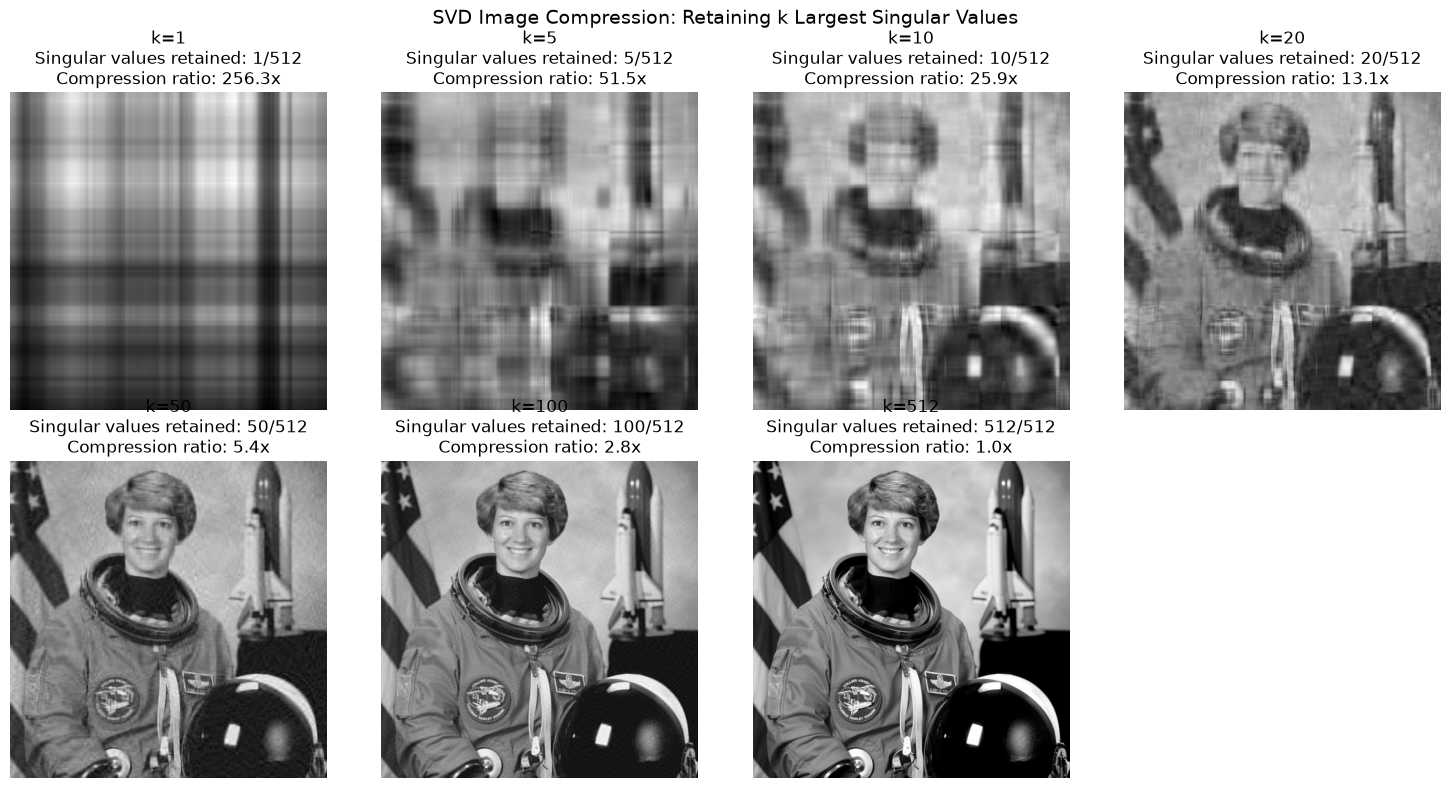

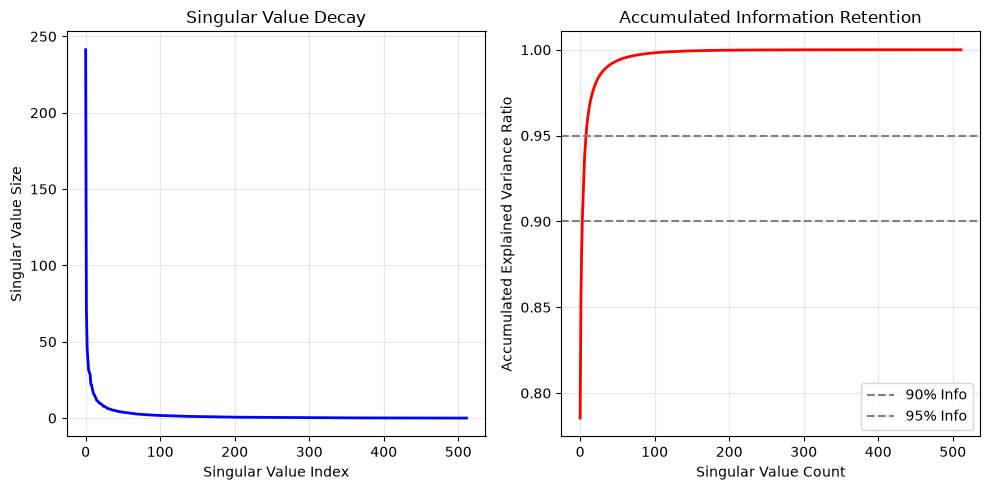

保留 90% 信息需要 4 个奇异值
保留 95% 信息需要 9 个奇异值
保留 99% 信息需要 38 个奇异值


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd
from skimage import data, color

# ---- 加载一张测试图片（灰阶） ----
# 使用 skimage 自带的图片
try:
    img = color.rgb2gray(data.astronaut())  # 512x512
except:
    # 如果 skimage 不可用，生成一个模拟图片
    print("skimage 不可用，使用模拟数据")
    np.random.seed(42)
    img = np.zeros((100, 100))
    # 画一个简单的矩形
    img[20:80, 20:80] = 1
    img[30:70, 30:70] = 0.5
    img = img + np.random.randn(100, 100) * 0.05
    img = np.clip(img, 0, 1)

print("=" * 60)
print("SVD 图像压缩")
print("=" * 60)
print(f"图像大小: {img.shape}")
print(f"总像素数: {img.size}")

# ---- SVD 分解 ----
U, S, Vt = svd(img, full_matrices=False)
print(f"\n奇异值数量: {len(S)}")

# ---- 不同 k 值下的压缩 ----
k_values = [1, 5, 10, 20, 50, 100, len(S)]
plt.figure(figsize=(15, 8))

for idx, k in enumerate(k_values):
    # 低秩近似：只保留前 k 个奇异值
    A_k = (U[:, :k] * S[:k]) @ Vt[:k, :]
    
    # 压缩比：原始图像大小 / 低秩近似图像大小，即像素数 / (k * (行数 + 列数 - k))
    compression_ratio = img.size / (k * (img.shape[0] + img.shape[1] - k))
    
    plt.subplot(2, 4, idx + 1)
    plt.imshow(A_k, cmap='gray')
    # plt.title(f'k={k}\n奇异值保留: {k}/{len(S)}\n压缩比: {compression_ratio:.1f}x')
    plt.title(f'k={k}\nSingular values retained: {k}/{len(S)}\nCompression ratio: {compression_ratio:.1f}x')
    plt.axis('off')

# plt.suptitle('SVD 图像压缩：保留 k 个最大奇异值', fontsize=14)
plt.suptitle('SVD Image Compression: Retaining k Largest Singular Values', fontsize=14)
plt.tight_layout()
plt.show()

# ---- 奇异值分布 ----
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(S, 'b-', linewidth=2)
# plt.xlabel('奇异值序号')
# plt.ylabel('奇异值大小')
# plt.title('奇异值衰减')
plt.xlabel('Singular Value Index')
plt.ylabel('Singular Value Size')
plt.title('Singular Value Decay')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
cumulative_variance = np.cumsum(S**2) / np.sum(S**2)
plt.plot(cumulative_variance, 'r-', linewidth=2)
plt.axhline(y=0.9, color='gray', linestyle='--', label='90% Info')
plt.axhline(y=0.95, color='gray', linestyle='--', label='95% Info')
# plt.xlabel('奇异值数量')
# plt.ylabel('累积解释方差比')
# plt.title('累积信息保留')
plt.xlabel('Singular Value Count')
plt.ylabel('Accumulated Explained Variance Ratio')
plt.title('Accumulated Information Retention')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ---- 找到需要保留的奇异值数量 ----
for threshold in [0.9, 0.95, 0.99]:
    n_keep = np.argmax(np.cumsum(S**2) >= threshold * np.sum(S**2)) + 1
    print(f"保留 {threshold*100:.0f}% 信息需要 {n_keep} 个奇异值")